In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd
from IPython.display import HTML
import time

from numcosmo_py import Nc, Ncm
from numcosmo_py.sky_match import (
    BestCandidates,
    Coordinates,
    DistanceMethod,
    SelectionCriteria,
    SkyMatch,
    SkyMatchResult,
)
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
set_rc_params_article(ncol=1)
Ncm.cfg_init()

Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)

# Mocks construction

In [2]:
# Constants
CLUSTER_LENGTH = 100
HALO_LENGTH = 200

RA_MIN, RA_MAX = -10.0, 10.0
DEC_MIN, DEC_MAX = -10.0, 10.0
Z_MIN, Z_MAX = 0.2, 0.5
LOGM_MIN, LOGM_MAX = 13.0, 15.0  # Mass in log10 solar masses
LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX = 10.0, 13.0

# Generate cluster positions, redshifts, and masses
cluster_ra = np.random.uniform(RA_MIN, RA_MAX, CLUSTER_LENGTH)
cluster_sin_dec = np.random.uniform(
    np.sin(np.radians(DEC_MIN)), np.sin(np.radians(DEC_MAX)), CLUSTER_LENGTH
)
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = np.random.uniform(Z_MIN, Z_MAX, CLUSTER_LENGTH)
cluster_logm = np.random.uniform(LOGM_MIN, LOGM_MAX, CLUSTER_LENGTH)
# Let's compute the cluster radii, and the 3D positions
cluster_r = np.array(dist.comoving_array(cosmo, cluster_z)) * cosmo.RH_Mpc()
cluster_x1 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.cos(np.radians(cluster_ra))
)
cluster_x2 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.sin(np.radians(cluster_ra))
)
cluster_x3 = cluster_r * np.sin(np.radians(cluster_dec))

# Generate halo positions, redshifts, and masses
# Lets first sample a halo < 5.0 Mpc from the cluster in each dimension
D_DIM = 5.0

halo_x1 = cluster_x1 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x2 = cluster_x2 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x3 = cluster_x3 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_ra = np.degrees(np.arctan2(halo_x2, halo_x1))
halo_dec = np.degrees(np.arcsin(halo_x3 / cluster_r))
halo_r = np.sqrt(halo_x1**2 + halo_x2**2 + halo_x3**2)
halo_z = [dist.inv_comoving(cosmo, r / cosmo.RH_Mpc()) for r in halo_r]

# Now for the halo masses we use the cluster's masses added a Gaussian noise
halo_logm = cluster_logm + np.random.normal(0, 1.0, CLUSTER_LENGTH)

# Finally we add 100 more halos randomly
DELTA_OBJECTS = HALO_LENGTH - CLUSTER_LENGTH
halo_ra = np.append(halo_ra, np.random.uniform(RA_MIN, RA_MAX, DELTA_OBJECTS))
halo_dec = np.append(halo_dec, np.random.uniform(DEC_MIN, DEC_MAX, DELTA_OBJECTS))
halo_z = np.append(halo_z, np.random.uniform(Z_MIN, Z_MAX, DELTA_OBJECTS))
halo_logm = np.append(
    halo_logm, np.random.uniform(LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX, DELTA_OBJECTS)
)

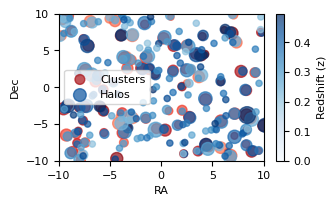

In [3]:
# Scale marker sizes with log mass
def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

fig, ax = plt.subplots()

# Scatter plot for clusters (fixed red color)
ax.scatter(
    cluster_ra,
    cluster_dec,
    c=cluster_z,
    cmap="Reds",
    s=cluster_sizes,
    label="Clusters",
    alpha=0.7,
    vmin=0.0,
)

# Scatter plot for halos (color varies with z, from light to dark blue)
halo_scatter = ax.scatter(
    halo_ra,
    halo_dec,
    c=halo_z,
    cmap="Blues",
    s=halo_sizes,
    label="Halos",
    alpha=0.7,
    vmin=0.0,
)

# Colorbar to indicate redshift values
color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(RA_MIN, RA_MAX)
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.legend()
plt.tight_layout()
plt.savefig("halos_clusters.pdf")
#plt.show()

In [4]:
# Create the astropy table for clusters
clusters = Table(
    [cluster_ra, cluster_dec, cluster_z, cluster_logm],
    names=["cluster_RA", "cluster_DEC", "cluster_z", "cluster_logM"],
)

# Create the astropy table for halos
halos = Table(
    [halo_ra, halo_dec, halo_z, halo_logm],
    names=["halo_RA", "halo_DEC", "halo_z", "halo_logM"],
)

# Create the Coordinates object for clusters
cluster_coords = Coordinates(RA="cluster_RA", DEC="cluster_DEC", z="cluster_z")

# Create the Coordinates object for halos
halo_coords = Coordinates(RA="halo_RA", DEC="halo_DEC", z="halo_z")

def show_pandas(df: pd.DataFrame):
    return HTML(df.to_html(float_format="%.2f", max_rows=10))


show_pandas(clusters.to_pandas())

,cluster_RA,cluster_DEC,cluster_z,cluster_logM
0,-5.65,-0.33,0.43,13.83
1,6.51,-8.81,0.44,13.20
2,7.07,9.85,0.25,13.55
3,4.02,6.92,0.45,13.32
4,8.27,-7.72,0.36,13.32
...,...,...,...,...
95,7.20,-3.60,0.34,14.49
96,5.83,-4.58,0.34,14.68
97,9.50,-8.67,0.36,13.13
98,8.32,-0.42,0.40,14.17


In [5]:
show_pandas(halos.to_pandas())

,halo_RA,halo_DEC,halo_z,halo_logM
0,-5.74,-0.34,0.43,13.32
1,6.54,-8.89,0.44,12.52
2,6.95,9.90,0.25,13.46
3,4.09,7.03,0.45,14.19
4,8.33,-7.90,0.37,14.40
...,...,...,...,...
195,5.26,-4.95,0.47,12.31
196,-6.97,-6.53,0.29,10.08
197,9.19,5.17,0.35,12.28
198,3.62,1.21,0.29,10.13


# 3D matching

In [6]:
# Create the SkyMatch object
sm = SkyMatch(clusters, cluster_coords, halos, halo_coords)

## Multiple Match

In [7]:
# Perform 3D matching
# We are keeping the number of nearest neighbors to 6
result = sm.match_3d(cosmo, n_nearest_neighbours=6)

def convert_table_multi_column(table):
    table["Index_matched"] = [np.array2string(i) for i in table["Index_matched"]]
    table["RA_matched"] = [
        np.array2string(ra, precision=2) for ra in table["RA_matched"]
    ]
    table["DEC_matched"] = [
        np.array2string(dec, precision=2) for dec in table["DEC_matched"]
    ]
    if "distances" in table.columns:
        table["distances"] = [
            np.array2string(dist, precision=2) for dist in table["distances"]
        ]
    table["z_matched"] = [np.array2string(z, precision=2) for z in table["z_matched"]]

    return table


show_pandas(convert_table_multi_column(result.to_table_complete()).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,-0.33,0.43,[ 0 114 36 79 131 92],[ 2.08 42.02 69.65 70.33 79.12 84.09],[-5.74 -6.59 -5.6 -7.9 -6.73 -7.31],[-0.34 -1.01 -3.32 -2.76 -1.2 -2.55],[0.43 0.41 0.45 0.44 0.39 0.39]
1,1,6.51,-8.81,0.44,[ 1 117 118 41 61 151],[ 1.9 41.93 52.95 52.99 69.65 70.23],[6.54 5.69 6.23 8.95 4.37 8.03],[-8.89 -7.89 -9.37 -8.65 -7.85 -6.22],[0.44 0.42 0.41 0.43 0.47 0.42]
2,2,7.07,9.85,0.25,[ 2 8 134 132 74 147],[ 3.16 52.62 84.51 102.77 116.56 118.15],[6.95 7.25 9.73 3.42 0.85 6.24],[9.9 6.28 9.55 8.7 9.74 6.7 ],[0.25 0.24 0.22 0.21 0.28 0.29]
3,3,4.02,6.92,0.45,[ 3 162 35 127 119 24],[ 2.76 35.33 56.33 61.26 70.46 72.57],[4.09 2.68 3.43 6.75 3.95 6.74],[7.03 6.1 4.42 7.3 5.09 7.48],[0.45 0.45 0.44 0.44 0.42 0.48]
4,4,8.27,-7.72,0.36,[ 4 97 121 78 133 186],[ 4.42 28.94 50.72 51.56 57.67 65.71],[8.33 9.53 7.92 7.17 6.64 5.34],[-7.9 -8.61 -6.36 -6.75 -7.96 -7.69],[0.37 0.36 0.39 0.39 0.39 0.34]
...,...,...,...,...,...,...,...,...,...
95,95,7.20,-3.60,0.34,[ 95 96 156 128 56 108],[ 1.19 32.15 41.28 51.7 52.05 59.9 ],[7.13 5.88 5.54 4.42 8.28 4.89],[-3.61 -4.74 -4.59 -2.88 -5.78 -5.82],[0.34 0.34 0.35 0.34 0.33 0.33]
96,96,5.83,-4.58,0.34,[ 96 156 95 108 128 186],[ 4.23 18.58 29.56 35.42 40.42 57.14],[5.88 5.54 7.13 4.89 4.42 5.34],[-4.74 -4.59 -3.61 -5.82 -2.88 -7.69],[0.34 0.35 0.34 0.33 0.34 0.34]
97,97,9.50,-8.67,0.36,[ 97 4 121 78 133 186],[ 2.15 27.69 72.51 75.78 78.15 84.26],[9.53 8.33 7.92 7.17 6.64 5.34],[-8.61 -7.9 -6.36 -6.75 -7.96 -7.69],[0.36 0.37 0.39 0.39 0.39 0.34]
98,98,8.32,-0.42,0.40,[ 98 53 146 125 101 178],[ 2.56 61.38 77.89 82.49 93.5 100.72],[8.22 7.97 6.09 6.32 6.31 5.81],[-0.37 2.18 -0.85 -3.88 -1.69 1.42],[0.4 0.42 0.37 0.41 0.45 0.36]


In [8]:
# Filter the results to keep only those with a distance less than 60 Mpc
mask = result.filter_mask_by_distance(60.0)

show_pandas(convert_table_multi_column(result.to_table_complete(mask=mask)).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,-0.33,0.43,[ 0 114],[ 2.08 42.02],[-5.74 -6.59],[-0.34 -1.01],[0.43 0.41]
1,1,6.51,-8.81,0.44,[ 1 117 118 41],[ 1.9 41.93 52.95 52.99],[6.54 5.69 6.23 8.95],[-8.89 -7.89 -9.37 -8.65],[0.44 0.42 0.41 0.43]
2,2,7.07,9.85,0.25,[2 8],[ 3.16 52.62],[6.95 7.25],[9.9 6.28],[0.25 0.24]
3,3,4.02,6.92,0.45,[ 3 162 35],[ 2.76 35.33 56.33],[4.09 2.68 3.43],[7.03 6.1 4.42],[0.45 0.45 0.44]
4,4,8.27,-7.72,0.36,[ 4 97 121 78 133],[ 4.42 28.94 50.72 51.56 57.67],[8.33 9.53 7.92 7.17 6.64],[-7.9 -8.61 -6.36 -6.75 -7.96],[0.37 0.36 0.39 0.39 0.39]
...,...,...,...,...,...,...,...,...,...
95,95,7.20,-3.60,0.34,[ 95 96 156 128 56 108],[ 1.19 32.15 41.28 51.7 52.05 59.9 ],[7.13 5.88 5.54 4.42 8.28 4.89],[-3.61 -4.74 -4.59 -2.88 -5.78 -5.82],[0.34 0.34 0.35 0.34 0.33 0.33]
96,96,5.83,-4.58,0.34,[ 96 156 95 108 128 186],[ 4.23 18.58 29.56 35.42 40.42 57.14],[5.88 5.54 7.13 4.89 4.42 5.34],[-4.74 -4.59 -3.61 -5.82 -2.88 -7.69],[0.34 0.35 0.34 0.33 0.34 0.34]
97,97,9.50,-8.67,0.36,[97 4],[ 2.15 27.69],[9.53 8.33],[-8.61 -7.9 ],[0.36 0.37]
98,98,8.32,-0.42,0.40,[98],[2.56],[8.22],[-0.37],[0.4]


In [9]:
# Plot the filtered results


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)


def plot_mask(mask):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the filtered results plotting a line connecting the cluster to all matched halos
    for i, (idx, m) in enumerate(zip(result.nearest_neighbours_indices, mask.array)):
        for halo_i in idx[m]:
            ax.plot(
                [cluster_ra[i], halo_ra[halo_i]],
                [cluster_dec[i], halo_dec[halo_i]],
                color="black",
                alpha=0.5,
            )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

    return fig


#plot_mask(mask)
#plt.show()

## Best Match

In [10]:
# Perform best match
best = result.select_best(mask=mask, selection_criteria=SelectionCriteria.DISTANCES)

show_pandas(convert_table_multi_column(result.to_table_best(best)).to_pandas())

,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched
0,0,-5.65,-0.33,0.43,0,-5.74,-0.34,0.43
1,1,6.51,-8.81,0.44,1,6.54,-8.89,0.44
2,2,7.07,9.85,0.25,2,6.95,9.9,0.25
3,3,4.02,6.92,0.45,3,4.09,7.03,0.45
4,4,8.27,-7.72,0.36,4,8.33,-7.9,0.37
...,...,...,...,...,...,...,...,...
95,95,7.20,-3.60,0.34,95,7.13,-3.61,0.34
96,96,5.83,-4.58,0.34,96,5.88,-4.74,0.34
97,97,9.50,-8.67,0.36,97,9.53,-8.61,0.36
98,98,8.32,-0.42,0.40,98,8.22,-0.37,0.4


In [11]:
# Plot the best matches


def plot_best(best):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the best matches plotting a line connecting the cluster to the best halos
    for cluster_i, halo_i in zip(best.query_indices, best.indices):
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig


#plot_best(best)
#plt.show()  

## Cross Match

In [12]:
# Perform cross match

cross = sm.invert_query_match()

cross_result = cross.match_3d(cosmo, n_nearest_neighbours=6)
cross_mask = cross_result.filter_mask_by_distance(60.0)

cross_best = cross_result.select_best(mask=cross_mask, selection_criteria=SelectionCriteria.DISTANCES)

cross_match = best.get_cross_match_indices(cross_best)

# Plot the cross matches


def plot_cross(cross_match):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the cross matches plotting a line connecting the cluster to the best halos
    for cluster_i, halo_i in cross_match.items():
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig


#plot_cross(cross_match)
#plt.show()

# 2D Matching

## Multiple Match

In [13]:
# Perform 2D matching  
# Keeping the number of nearest neighbors to 6 
start_m = time.perf_counter()
result = sm.match_2d(
    cosmo, n_nearest_neighbours=6, distance_method=DistanceMethod.QUERY_RADIUS
)
end_m = time.perf_counter()

time_m = end_m - start_m

print(f"Execution time: {time_m:.6f} seconds")


#show_pandas(convert_table_multi_column(result.to_table_complete()).to_pandas())

Execution time: 0.105272 seconds


In [14]:
# Apply a distance filter to retain only matches within 60 Mpc
mask = result.filter_mask_by_distance(60.0)

# Further refine by keeping only matches with redshift < 0.02
mask = result.filter_mask_by_redshift_proximity(0.02, mask=mask)
show_pandas(convert_table_multi_column(result.to_table_complete(mask)).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,-0.33,0.43,[ 0 114 131 170],[ 1.93 24.13 28.8 32.83],[-5.74 -6.59 -6.73 -4.21],[-0.34 -1.01 -1.2 -0.98],[0.43 0.41 0.39 0.48]
1,1,6.51,-8.81,0.44,[ 1 118 133 117],[ 1.8 13.12 18.23 26.02],[6.54 6.23 6.64 5.69],[-8.89 -9.37 -7.96 -7.89],[0.44 0.41 0.39 0.42]
2,2,7.07,9.85,0.25,[ 2 134 147],[ 1.86 38.17 47.04],[6.95 9.73 6.24],[9.9 9.55 6.7 ],[0.25 0.22 0.29]
3,3,4.02,6.92,0.45,[ 3 162 119],[ 2.75 33.45 39.18],[4.09 2.68 3.95],[7.03 6.1 5.09],[0.45 0.45 0.42]
4,4,8.27,-7.72,0.36,[ 4 121 78 97 151],[ 3.43 26.47 27.59 28.67 28.69],[8.33 7.92 7.17 9.53 8.03],[-7.9 -6.36 -6.75 -8.61 -6.22],[0.37 0.39 0.39 0.36 0.42]
...,...,...,...,...,...,...,...,...,...
95,95,7.20,-3.60,0.34,[ 95 96 156],[ 1.17 31.33 34.74],[7.13 5.88 5.54],[-3.61 -4.74 -4.59],[0.34 0.34 0.35]
96,96,5.83,-4.58,0.34,[ 96 156 144],[ 3.13 5.31 22.88],[5.88 5.54 5.23],[-4.74 -4.59 -5.69],[0.34 0.35 0.3 ]
97,97,9.50,-8.67,0.36,[ 97 4 121],[ 1.23 26.11 52.2 ],[9.53 8.33 7.92],[-8.61 -7.9 -6.36],[0.36 0.37 0.39]
98,98,8.32,-0.42,0.40,[ 98 146 101 53],[ 2.26 45.46 47.54 52.52],[8.22 6.09 6.31 7.97],[-0.37 -0.85 -1.69 2.18],[0.4 0.37 0.45 0.42]


In [15]:
#plot_mask(mask)
#plt.tight_layout()
#plt.savefig("multipe_match_proximity.pdf")
#plt.show()

## Best Match

In [16]:
# Find the best match for each cluster

start_b = time.perf_counter()
best = result.select_best(
    selection_criteria=SelectionCriteria.MORE_MASSIVE,
    mask=mask,
    more_massive_column="halo_logM",
)
end_b = time.perf_counter()

time_b = end_b - start_b
print(f"Execution time: {time_b:.6f} seconds")



show_pandas(
    convert_table_multi_column(
        result.to_table_best(
            best,
            query_properties={"cluster_logM": "cluster_logM"},
            match_properties={"halo_logM": "halo_logM"},
        )
    ).to_pandas()
)

Execution time: 0.002277 seconds


,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched,cluster_logM,halo_logM
0,0,-5.65,-0.33,0.43,0,-5.74,-0.34,0.43,13.83,13.32
1,1,6.51,-8.81,0.44,118,6.23,-9.37,0.41,13.20,12.56
2,2,7.07,9.85,0.25,2,6.95,9.9,0.25,13.55,13.46
3,3,4.02,6.92,0.45,3,4.09,7.03,0.45,13.32,14.19
4,4,8.27,-7.72,0.36,78,7.17,-6.75,0.39,13.32,15.36
...,...,...,...,...,...,...,...,...,...,...
95,95,7.20,-3.60,0.34,96,5.88,-4.74,0.34,14.49,14.90
96,96,5.83,-4.58,0.34,96,5.88,-4.74,0.34,14.68,14.90
97,97,9.50,-8.67,0.36,4,8.33,-7.9,0.37,13.13,14.40
98,98,8.32,-0.42,0.40,98,8.22,-0.37,0.4,14.17,14.42


In [17]:
#plot_best(best)
#plt.savefig("best_match_proximity.pdf")
#plt.show()

## Cross Match

In [18]:
# Find the best match for each halo





cross = sm.invert_query_match()

start_c = time.perf_counter()

cross_result = cross.match_2d(cosmo, n_nearest_neighbours=6)

cross_mask = cross_result.filter_mask_by_distance(60.0)
cross_mask = cross_result.filter_mask_by_redshift_proximity(0.02, mask=cross_mask)

cross_best = cross_result.select_best(
    selection_criteria=SelectionCriteria.REDSHIFT_PROXIMITY, mask=cross_mask
)


cross_match = best.get_cross_match_indices(cross_best)

end_c = time.perf_counter()

time_c = end_c - start_c

print(f"Execution time: {time_c:.6f} seconds")

show_pandas(
    convert_table_multi_column(
        cross_result.to_table_best(
            cross_best,
            query_properties={"halo_logM": "halo_logM"},
            match_properties={"cluster_logM": "cluster_logM"},
        )
    ).to_pandas()
)

Execution time: 0.120879 seconds


,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched,halo_logM,cluster_logM
0,0,-5.74,-0.34,0.43,0,-5.65,-0.33,0.43,13.32,13.83
1,1,6.54,-8.89,0.44,1,6.51,-8.81,0.44,12.52,13.20
2,2,6.95,9.90,0.25,2,7.07,9.85,0.25,13.46,13.55
3,3,4.09,7.03,0.45,3,4.02,6.92,0.45,14.19,13.32
4,4,8.33,-7.90,0.37,4,8.27,-7.72,0.36,14.40,13.32
...,...,...,...,...,...,...,...,...,...,...
184,194,-9.49,7.31,0.34,67,-8.75,7.69,0.33,12.92,13.70
185,196,-6.97,-6.53,0.29,19,-7.42,-7.53,0.3,10.08,13.85
186,197,9.19,5.17,0.35,57,9.15,1.98,0.32,12.28,13.95
187,198,3.62,1.21,0.29,80,2.87,2.41,0.28,10.13,13.65


In [19]:
#plot_cross(cross_match)
#plt.tight_layout()
#plt.savefig("cross_match_proximity.pdf")
#plt.show()

In [20]:
# Convert dictionary to DataFrame for better visualization
cross_match_df = pd.DataFrame(
    list(cross_match.items()), columns=["Cluster ID", "Matched Halo ID"]
)

# Compute correctness
wrong = cross_match_df["Cluster ID"] != cross_match_df["Matched Halo ID"]
right = ~wrong  # Logical NOT for correct matches

# Add correctness column
cross_match_df["Correct Match"] = right

cross_match_df

,Cluster ID,Matched Halo ID,Correct Match
0,0,0,True
1,1,118,False
2,2,2,True
3,3,3,True
4,5,5,True
...,...,...,...
63,90,90,True
64,92,92,True
65,94,94,True
66,96,96,True


In [21]:
# Display match statistics
HTML(
    pd.DataFrame(
        {
            "Total Matches": [len(cross_match)],
            "Correct Matches": [right.sum()],
            "Wrong Matches": [wrong.sum()],
        }
    ).to_html(index=False)
)

Total Matches,Correct Matches,Wrong Matches
68,66,2


In [22]:
print(time_m)
print(time_b)
print(time_c)
print(time_m+time_b+time_c)

0.10527181415818632
0.0022772829979658127
0.12087924708612263
0.22842834424227476


In [23]:
#time for each run 2D seconds


#100,200 = 0.146889 multiple +  0.000385 best + 0.168425 cross = 0,315699 seconds, 66/68(100)
#1000, 2000 = 0.155581 multiple + 0.04131448804400861 best + 0.382348 cross =  0.5804, 616/635(1000)
#10000, 20000 = 0.26347 multiple + 0.173033 best + 1.86618 cross =  2.30269, 4117/5061(10000)
#100000, 200000 =  1.4917 multiple + 2.14627 best + 17.979508 cross = 21.617507, 4761/39562(100000)
#1000000, 2000000 = 38.57229 multiple + 18.7347 best + 17.979508 cross = 267.9890, 4767/393525(1000000)